In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt




In [14]:
from sklearn.datasets import load_wine
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [15]:
data=load_wine()
X=data.data
df=pd.DataFrame(X,columns=data.feature_names)
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [16]:
df.isnull().sum()

alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
dtype: int64

In [17]:
scaler=StandardScaler()
X_scaled_scaler=scaler.fit_transform(X)


In [18]:
from scipy.cluster.hierarchy import dendrogram,linkage,fcluster

In [19]:
linked=linkage(X_scaled_scaler,method='ward')
linked[:10]

array([[  9.        ,  47.        ,   1.16411367,   2.        ],
       [131.        , 133.        ,   1.19160238,   2.        ],
       [ 11.        ,  12.        ,   1.20935571,   2.        ],
       [ 15.        ,  53.        ,   1.22551046,   2.        ],
       [ 92.        , 107.        ,   1.24538798,   2.        ],
       [ 34.        ,  37.        ,   1.26841838,   2.        ],
       [  0.        ,  20.        ,   1.28789316,   2.        ],
       [ 16.        ,  17.        ,   1.2917937 ,   2.        ],
       [164.        , 172.        ,   1.30048379,   2.        ],
       [ 22.        ,  29.        ,   1.33566687,   2.        ]])

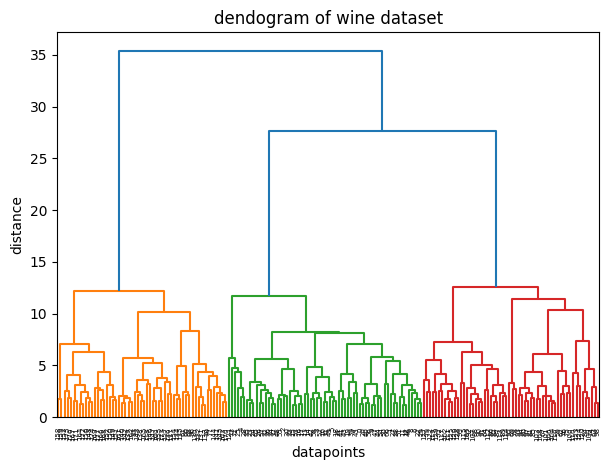

In [20]:
plt.figure(figsize=(7,5))
dendrogram(linked)
plt.title("dendogram of wine dataset")
plt.xlabel("datapoints")
plt.ylabel("distance")
plt.show()

In [21]:
from sklearn.metrics import silhouette_score

sil_scores = []
for n_clusters in range(2, 11):
    model = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
    labels = model.fit_predict(X_scaled_scaler)
    score = silhouette_score(X_scaled_scaler, labels)
    sil_scores.append((n_clusters, score))
    print(f"n_clusters={n_clusters}, silhouette_score={score:.4f}")

best_n, best_score = max(sil_scores, key=lambda x: x[1])
print(f"Best n_clusters = {best_n} with silhouette score = {best_score:.4f}")

final_model = AgglomerativeClustering(n_clusters=best_n, linkage='ward')
df['agglomerative_cluster'] = final_model.fit_predict(X_scaled_scaler)
df['agglomerative_cluster'].value_counts().sort_index()

n_clusters=2, silhouette_score=0.2670
n_clusters=3, silhouette_score=0.2774
n_clusters=4, silhouette_score=0.2258
n_clusters=5, silhouette_score=0.1867
n_clusters=6, silhouette_score=0.1797
n_clusters=7, silhouette_score=0.1869
n_clusters=8, silhouette_score=0.1883
n_clusters=9, silhouette_score=0.1917
n_clusters=10, silhouette_score=0.1986
Best n_clusters = 3 with silhouette score = 0.2774


agglomerative_cluster
0    58
1    56
2    64
Name: count, dtype: int64

In [22]:
model=AgglomerativeClustering(
    n_clusters=3,
    linkage='ward')
labels=model.fit_predict(X_scaled_scaler)
(labels)


array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 1, 1, 0, 0, 0, 2,
       2, 0, 1, 0, 1, 2, 0, 2, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1])

In [23]:
from sklearn.metrics import silhouette_score

labels = model.fit_predict(X_scaled_scaler)
score = silhouette_score(X_scaled_scaler, labels)

print("Silhouette Score:", score)

Silhouette Score: 0.2774439826952266


In [25]:

df['cluster'] = labels
df.head()
df.groupby('cluster').mean()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,agglomerative_cluster
cluster,,,,,,,,,,,,,,
0,12.203966,1.938966,2.215172,20.208621,92.551724,2.262931,2.088103,0.355345,1.686552,2.895345,1.060000,2.862241,501.431034,0.0
1,13.061607,3.166607,2.412857,21.003571,99.857143,1.694286,0.847857,0.449464,1.129286,6.850179,0.721000,1.727321,624.946429,1.0
2,13.669219,1.970000,2.463125,17.528125,106.156250,2.850000,3.009688,0.291094,1.908125,5.450000,1.071406,3.158437,1076.046875,2.0


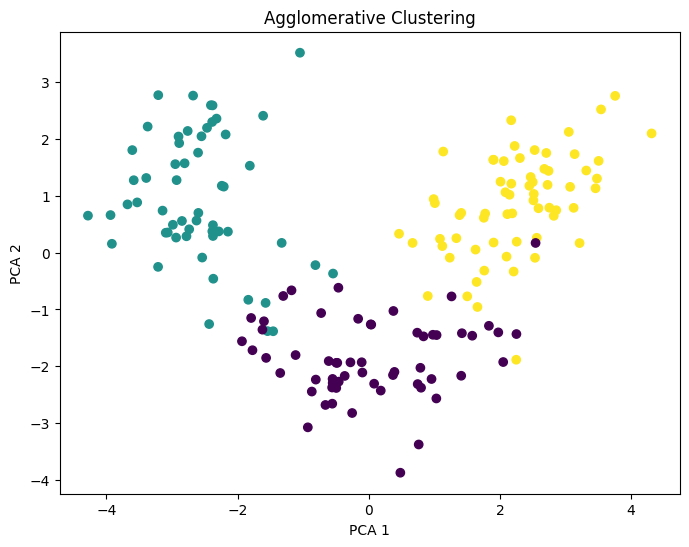

In [27]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X2 = pca.fit_transform(X_scaled_scaler)

plt.figure(figsize=(8, 6))
plt.scatter(X2[:, 0], X2[:, 1], c=labels, cmap='viridis')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('Agglomerative Clustering')
plt.show()

In [28]:
cluster_0 = df[df['cluster'] == 0]
cluster_0.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,agglomerative_cluster,cluster
59,12.37,0.94,1.36,10.6,88.0,1.98,0.57,0.28,0.42,1.95,1.05,1.82,520.0,0,0
62,13.67,1.25,1.92,18.0,94.0,2.10,1.79,0.32,0.73,3.80,1.23,2.46,630.0,0,0
63,12.37,1.13,2.16,19.0,87.0,3.50,3.10,0.19,1.87,4.45,1.22,2.87,420.0,0,0
64,12.17,1.45,2.53,19.0,104.0,1.89,1.75,0.45,1.03,2.95,1.45,2.23,355.0,0,0
67,12.37,1.17,1.92,19.6,78.0,2.11,2.00,0.27,1.04,4.68,1.12,3.48,510.0,0,0


In [29]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

# Scaling
X_scaled = StandardScaler().fit_transform(X)

for k in range(2, 7):
    model = AgglomerativeClustering(
        n_clusters=k,
        linkage='ward'
    )
    
    labels = model.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    
    print(f"k={k}, Silhouette Score={score:.4f}")

k=2, Silhouette Score=0.2670
k=3, Silhouette Score=0.2774
k=4, Silhouette Score=0.2258
k=5, Silhouette Score=0.1867
k=6, Silhouette Score=0.1797


In [31]:
import numpy as np

unique, counts = np.unique(labels, return_counts=True)

for cluster, count in zip(unique, counts):
    print(f"Cluster {cluster}: {count} samples")

Cluster 0: 30 samples
Cluster 1: 58 samples
Cluster 2: 36 samples
Cluster 3: 28 samples
Cluster 4: 20 samples
Cluster 5: 6 samples


Dataset Shape: (178, 13)
k=2, Silhouette Score=0.2670
k=3, Silhouette Score=0.2774
k=4, Silhouette Score=0.2258
k=5, Silhouette Score=0.1867
k=6, Silhouette Score=0.1797


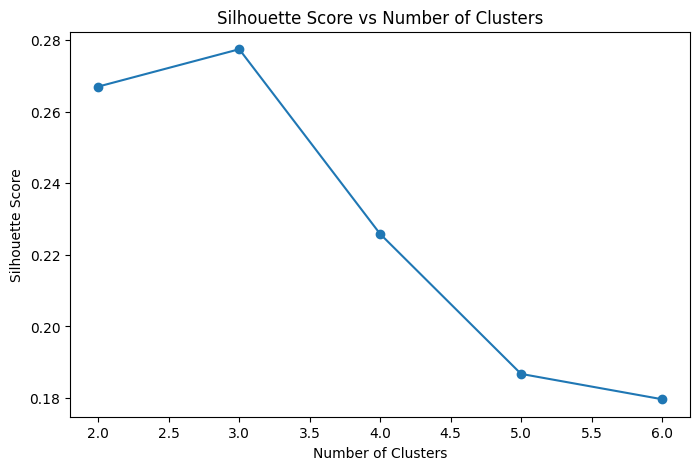

Final Silhouette Score: 0.2774439826952266
Cluster 0: 58 samples
Cluster 1: 56 samples
Cluster 2: 64 samples


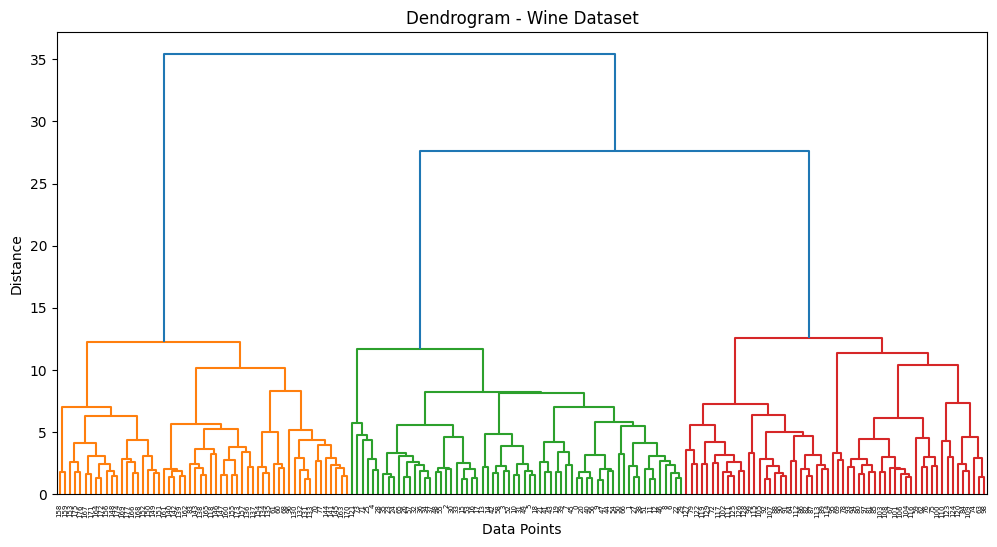

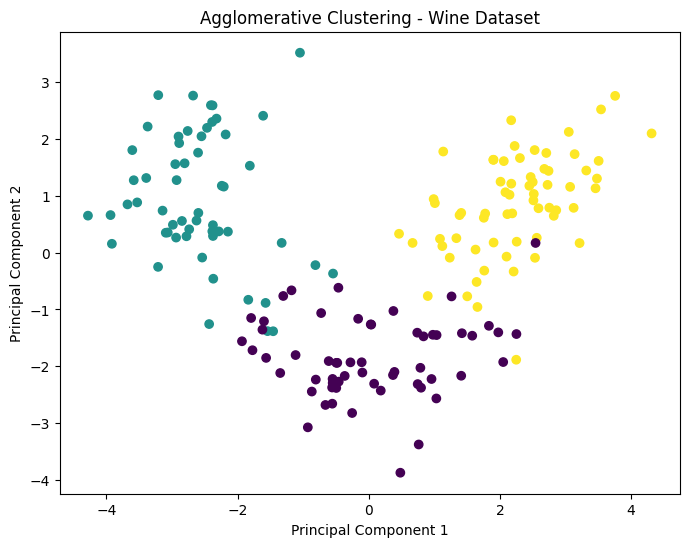


Cluster Means:
          alcohol  malic_acid       ash  alcalinity_of_ash  magnesium  \
Cluster                                                                 
0       -0.984077   -0.356716 -0.553216           0.214306  -0.504823   
1        0.075338    0.745293  0.169390           0.453018   0.008115   
2        0.825899   -0.328857  0.353136          -0.590606   0.450396   

         total_phenols  flavanoids  nonflavanoid_phenols  proanthocyanins  \
Cluster                                                                     
0            -0.051565    0.059067             -0.052449         0.167592   
1            -0.962723   -1.186099              0.705947        -0.808785   
2             0.889114    0.984307             -0.570172         0.555807   

         color_intensity       hue  od280/od315_of_diluted_wines   proline  
Cluster                                                                     
0              -0.935539  0.449924                      0.353896 -0.781673  
1

In [32]:
# ==========================================
# 1. Import Libraries
# ==========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.cluster.hierarchy as sch

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score


# ==========================================
# 2. Load Wine Dataset
# ==========================================

wine = load_wine()

X = wine.data
y = wine.target

feature_names = wine.feature_names

print("Dataset Shape:", X.shape)


# ==========================================
# 3. Standardization
# ==========================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)


# ==========================================
# 4. Find Best Number of Clusters
# ==========================================

k_values = range(2, 7)

scores = []

for k in k_values:

    model = AgglomerativeClustering(
        n_clusters=k,
        linkage='ward'
    )

    labels = model.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels
    )

    scores.append(score)

    print(
        f"k={k}, Silhouette Score={score:.4f}"
    )


# ==========================================
# 5. Plot Silhouette Scores
# ==========================================

plt.figure(figsize=(8, 5))

plt.plot(
    list(k_values),
    scores,
    marker='o'
)

plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs Number of Clusters")

plt.show()


# ==========================================
# 6. Final Model
# ==========================================

final_model = AgglomerativeClustering(
    n_clusters=3,
    linkage='ward'
)

final_labels = final_model.fit_predict(X_scaled)


# ==========================================
# 7. Final Silhouette Score
# ==========================================

final_score = silhouette_score(
    X_scaled,
    final_labels
)

print(
    "Final Silhouette Score:",
    final_score
)


# ==========================================
# 8. Cluster Sizes
# ==========================================

unique, counts = np.unique(
    final_labels,
    return_counts=True
)

for cluster, count in zip(unique, counts):

    print(
        f"Cluster {cluster}: {count} samples"
    )


# ==========================================
# 9. Dendrogram
# ==========================================

plt.figure(figsize=(12, 6))

sch.dendrogram(
    sch.linkage(
        X_scaled,
        method='ward'
    )
)

plt.title("Dendrogram - Wine Dataset")
plt.xlabel("Data Points")
plt.ylabel("Distance")

plt.show()


# ==========================================
# 10. PCA Visualization
# ==========================================

pca = PCA(
    n_components=2
)

X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=final_labels
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.title(
    "Agglomerative Clustering - Wine Dataset"
)

plt.show()


# ==========================================
# 11. Cluster Means
# ==========================================

cluster_df = pd.DataFrame(
    X_scaled,
    columns=feature_names
)

cluster_df['Cluster'] = final_labels

print("\nCluster Means:")

print(
    cluster_df.groupby('Cluster').mean()
)


# ==========================================
# 12. Compare with Actual Classes
# ==========================================

ari = adjusted_rand_score(
    y,
    final_labels
)

print(
    "\nAdjusted Rand Index:",
    ari
)


# ==========================================
# 13. Cross Tabulation
# ==========================================

comparison = pd.crosstab(
    y,
    final_labels
)

print("\nActual Class vs Cluster:")

print(comparison)